In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
inspections = pd.read_csv(r'/media/moccaram/54FA0D06FA0CE6581/chicago-food-inspections/data/processed/inspections_clean.csv')

In [5]:
inspections 

,inspection_id,dba_name,license,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location,has_location
0,2641217,CHIANG MAI NIGHT BAZAAR,3095746,Restaurant,High,215 W NORTH AVE,CHICAGO,IL,60610,2026-08-14,License,Pass,49. NON-FOOD/FOOD CONTACT SURFACES CLEAN - Com...,41.911048,-87.635382,"\n, \n(41.911047541225514, -87.63538198007993)",True
1,2641226,NAPLES PIZZA 3,2718389,Restaurant,High,2819 W 63RD ST,CHICAGO,IL,60629,2026-08-14,Complaint Re-Inspection,Pass w/ Conditions,"38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - ...",41.778995,-87.694210,"\n, \n(41.778994736359884, -87.69421036159837)",True
2,2641210,SUBWAY,1771904,Restaurant,High,5630 W ROOSEVELT RD,CHICAGO,IL,60644,2026-08-14,Canvass Re-Inspection,Pass,51. PLUMBING INSTALLED; PROPER BACKFLOW DEVICE...,41.865686,-87.765670,"\n, \n(41.86568627741837, -87.76566985156941)",True
3,2641222,PAPA T'S ITALIANO,1166821,Restaurant,High,2843 - 2847 W 63RD ST,CHICAGO,IL,60629,2026-08-14,Canvass Re-Inspection,Pass,36. THERMOMETERS PROVIDED & ACCURATE - Comment...,41.778981,-87.695090,"\n, \n(41.77898082071523, -87.69509004304912)",True
4,2641215,BIRDMAN RAMEN,3010783,Restaurant,High,800 W BELMONT AVE,CHICAGO,IL,60657,2026-08-14,Complaint Re-Inspection,Fail,"38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - ...",41.940090,-87.649310,"\n, \n(41.94009012484825, -87.64930995909579)",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312955,67733,WOLCOTT'S,1992040,Restaurant,High,1834 W MONTROSE AVE,CHICAGO,IL,60613,2010-01-04,License Re-Inspection,Pass,NaN,41.961606,-87.675967,"(41.961605669949854, -87.67596676683779)",True
312956,104236,TEMPO CAFE,80916,Restaurant,High,6 E CHESTNUT ST,CHICAGO,IL,60611,2010-01-04,Canvass,Fail,18. NO EVIDENCE OF RODENT OR INSECT OUTER OPEN...,41.898431,-87.628009,"(41.89843137207629, -87.6280091630558)",True
312957,67732,WOLCOTT'S,1992039,Restaurant,High,1834 W MONTROSE AVE,CHICAGO,IL,60613,2010-01-04,License Re-Inspection,Pass,NaN,41.961606,-87.675967,"(41.961605669949854, -87.67596676683779)",True
312958,67757,DUNKIN DONUTS/BASKIN-ROBBINS,1380279,Restaurant,Medium,100 W RANDOLPH ST,CHICAGO,IL,60601,2010-01-04,Tag Removal,Pass,NaN,41.884586,-87.631010,"(41.88458626715456, -87.63101044588599)",True


1. Pass-Rate Over Time & Inspection Mix

In [8]:
print(type(inspections['inspection_date']))

<class 'pandas.Series'>


In [9]:
inspections['inspection_date'].head(3)

0    2026-08-14
1    2026-08-14
2    2026-08-14
Name: inspection_date, dtype: str

In [10]:
inspections['inspection_date'] = pd.to_datetime(inspections['inspection_date'])
inspections['year'] = inspections['inspection_date'].dt.year 
inspections['is_fail'] = (inspections['results'] == 'Fail')

In [12]:
inspections['inspection_type'].value_counts().head(20)

inspection_type
Canvass                                   161744
License                                    41823
Canvass Re-Inspection                      34892
Complaint                                  29695
License Re-Inspection                      12726
Complaint Re-Inspection                    12377
Short Form Complaint                        9228
Non-Inspection                              5609
Suspected Food Poisoning                    1012
Consultation                                 673
License-Task Force                           603
Tag Removal                                  601
Recent Inspection                            543
Out of Business                              282
Task Force Liquor 1475                       252
Suspected Food Poisoning Re-inspection       229
Complaint-Fire                               160
Short Form Fire-Complaint                    113
No Entry                                      60
Special Events (Festivals)                    59
Name

In [15]:
#Focus on the big three inspection types: Canvass, Complaint, and License to keep the noise down.
top_types = ['Canvass', 'Complaint', 'License']
mix_df = inspections[inspections['inspection_type'].isin(top_types)]
mix_grouped = mix_df.groupby(['year', 'inspection_type']).size().unstack()

In [16]:
#Fail Rate Data
fail_rate_all = inspections.groupby('year')['is_fail'].mean()
fail_rate_canvass = inspections[inspections['inspection_type'] == 'Canvass'].groupby('year')['is_fail'].mean()


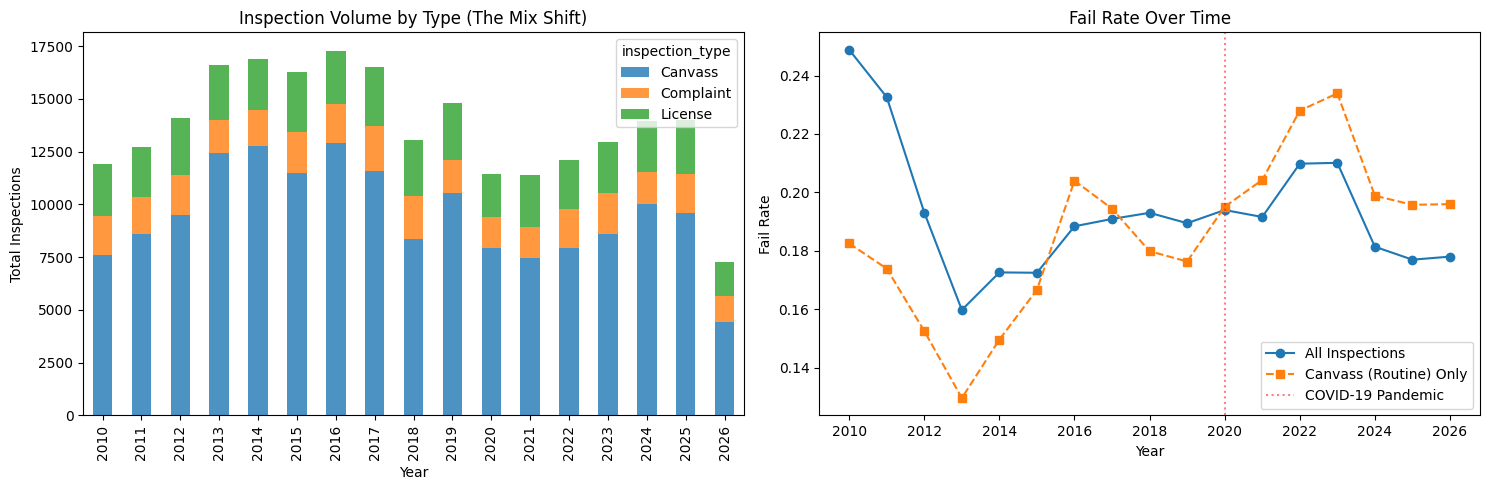

In [18]:
#Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


#Chart 1: Volume Mix
mix_grouped.plot(kind='bar', stacked=True, ax = axes[0], alpha=0.8)
axes[0].set_title('Inspection Volume by Type (The Mix Shift)')
axes[0].set_ylabel('Total Inspections') 
axes[0].set_xlabel('Year')


#Chart 2: Fail Rate (All vs Routine)
axes[1].plot(fail_rate_all.index, fail_rate_all.values, label='All Inspections', marker='o')
axes[1].plot(fail_rate_canvass.index, fail_rate_canvass.values, label='Canvass (Routine) Only', marker='s', linestyle='--')
axes[1].axvline(x=2020, color='red', linestyle=':', alpha=0.5, label='COVID-19 Pandemic')
axes[1].set_title('Fail Rate Over Time')
axes[1].set_ylabel('Fail Rate')
axes[1].set_xlabel('Year')
axes[1].legend()

plt.tight_layout()
plt.show()

2. Seasonality Check

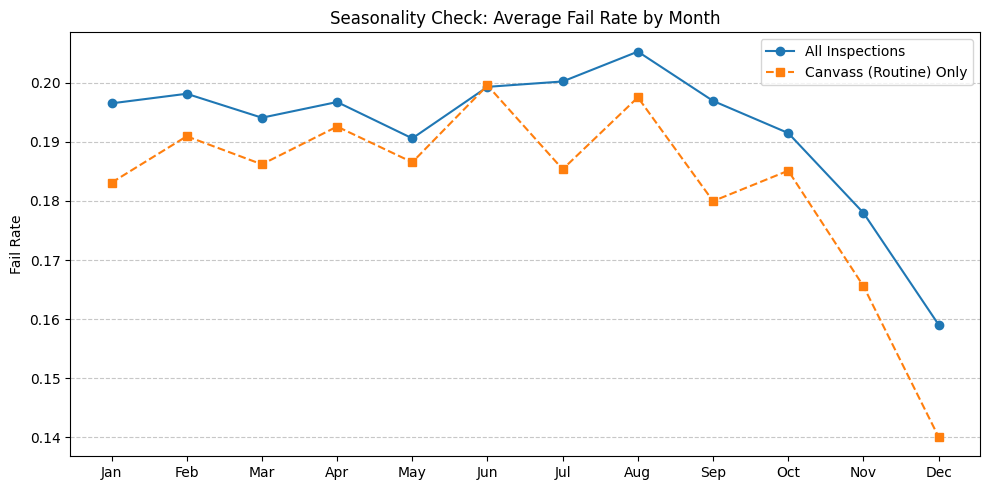

In [19]:
# Extract the month (1 = January, 12 = December)
inspections['month'] = inspections['inspection_date'].dt.month

# Calculate fail rates by month across all years
seasonal_fail_all = inspections.groupby('month')['is_fail'].mean()
seasonal_fail_canvass = inspections[inspections['inspection_type'] == 'Canvass'].groupby('month')['is_fail'].mean()

# Plotting the seasonality
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(seasonal_fail_all.index, seasonal_fail_all.values, marker='o', label='All Inspections')
ax.plot(seasonal_fail_canvass.index, seasonal_fail_canvass.values, marker='s', linestyle='--', label='Canvass (Routine) Only')

# Formatting for readability
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_title('Seasonality Check: Average Fail Rate by Month')
ax.set_ylabel('Fail Rate')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

3. Top Violation Codes (Post-2018)

In [21]:
violations = pd.read_csv(r'/media/moccaram/54FA0D06FA0CE6581/chicago-food-inspections/data/processed/violations_long.csv')

In [22]:
violations.head(3)

,inspection_id,violation_code,violation_description,comments,inspection_date,era
0,2641217,49,NON-FOOD/FOOD CONTACT SURFACES CLEAN,OBSERVED INTERIOR CAVITY OF BOTH REACH-IN LINE...,2026-08-14,post_2018
1,2641217,51,PLUMBING INSTALLED; PROPER BACKFLOW DEVICES,OBSERVED THE FOLLOWING PLUMBING FIXTURES IN PO...,2026-08-14,post_2018
2,2641217,55,"PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN",OBSERVED SEVERAL LARGE UNUSED EQUIPMENT ITEMS ...,2026-08-14,post_2018


In [25]:
violations['era'].value_counts()

era
pre_2018     520542
post_2018    495993
Name: count, dtype: int64

/tmp/ipykernel_48951/1239524741.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_violations.values, y=top_15_violations.index, palette='viridis', ax=ax)


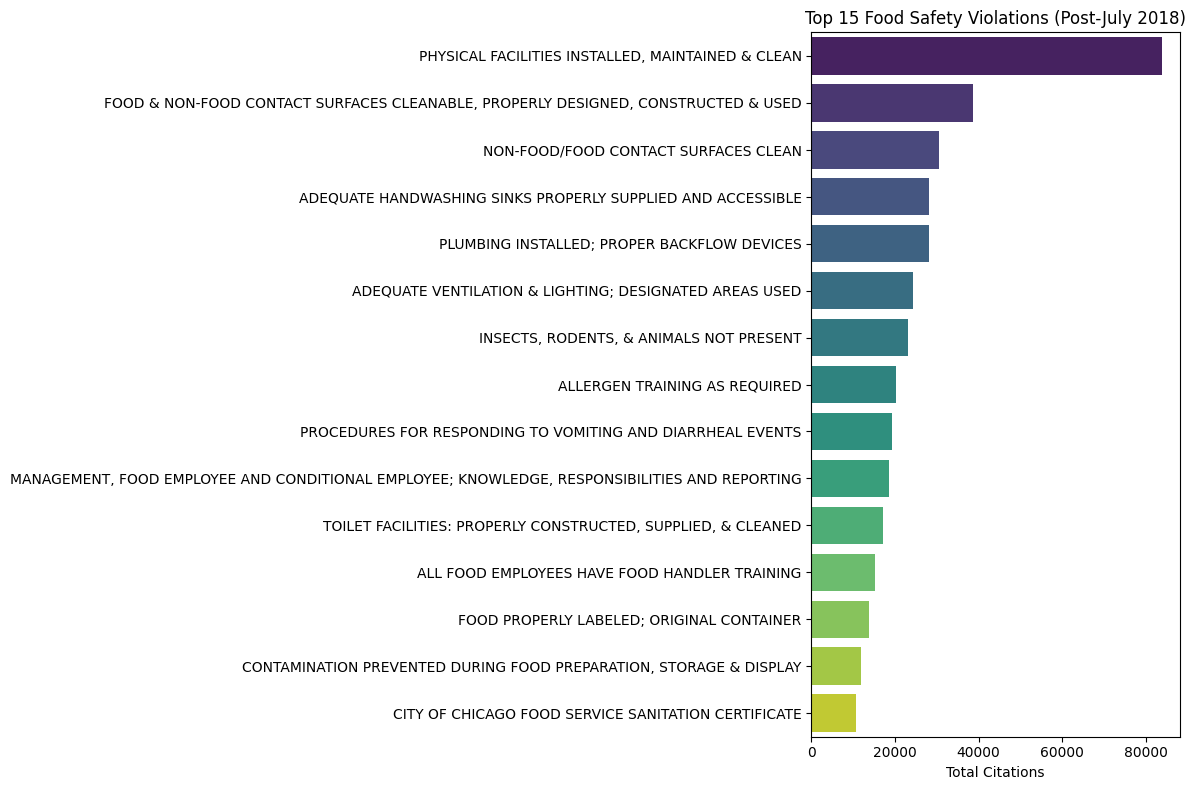

In [26]:
# 1. Filter for the modern era
modern_violations = violations[violations['era'] == 'post_2018']

# 2. Get the top 15 most frequent violation descriptions
top_15_violations = modern_violations['violation_description'].value_counts().head(15)

# 3. Plot as a horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Using seaborn for a cleaner look, but standard matplotlib works too
sns.barplot(x=top_15_violations.values, y=top_15_violations.index, palette='viridis', ax=ax)

ax.set_title('Top 15 Food Safety Violations (Post-July 2018)')
ax.set_xlabel('Total Citations')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

4. Fail Rate by Facility Type

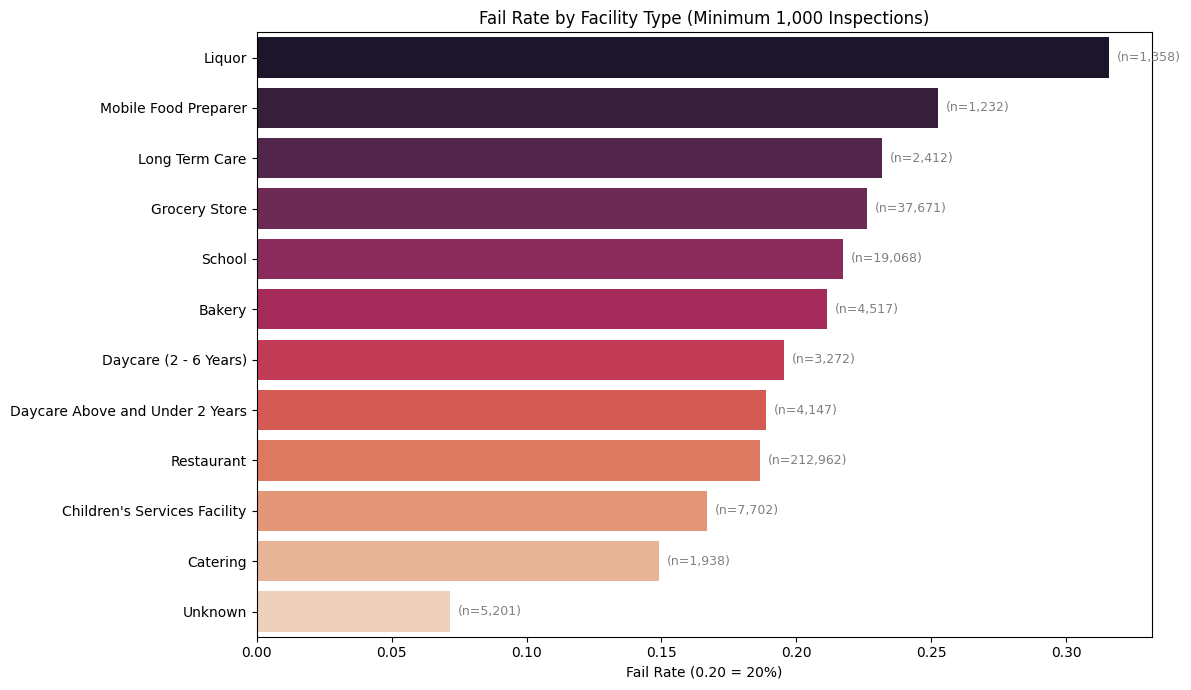

In [27]:
# 1. Group by facility type to get both volume (count) and fail rate (mean)
facility_stats = inspections.groupby('facility_type')['is_fail'].agg(['count', 'mean']).reset_index()

# 2. Filter out the noise: only keep categories with at least 1,000 total inspections
facility_stats_clean = facility_stats[facility_stats['count'] >= 1000].copy()

# 3. Sort by the fail rate descending
facility_stats_clean = facility_stats_clean.sort_values(by='mean', ascending=False)

# 4. Plot as a horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=facility_stats_clean, 
    x='mean', 
    y='facility_type', 
    hue='facility_type',
    palette='rocket',
    legend=False
)

ax.set_title('Fail Rate by Facility Type (Minimum 1,000 Inspections)')
ax.set_xlabel('Fail Rate (0.20 = 20%)')
ax.set_ylabel('')

# Add the (n=X) text to the end of each bar to show sample size
for i, p in enumerate(ax.patches):
    width = p.get_width()
    count = facility_stats_clean.iloc[i]['count']
    ax.text(width + 0.003, p.get_y() + p.get_height()/2., f'(n={int(count):,})', 
            va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

5. Fail Rate by Risk Category

/tmp/ipykernel_48951/627271715.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


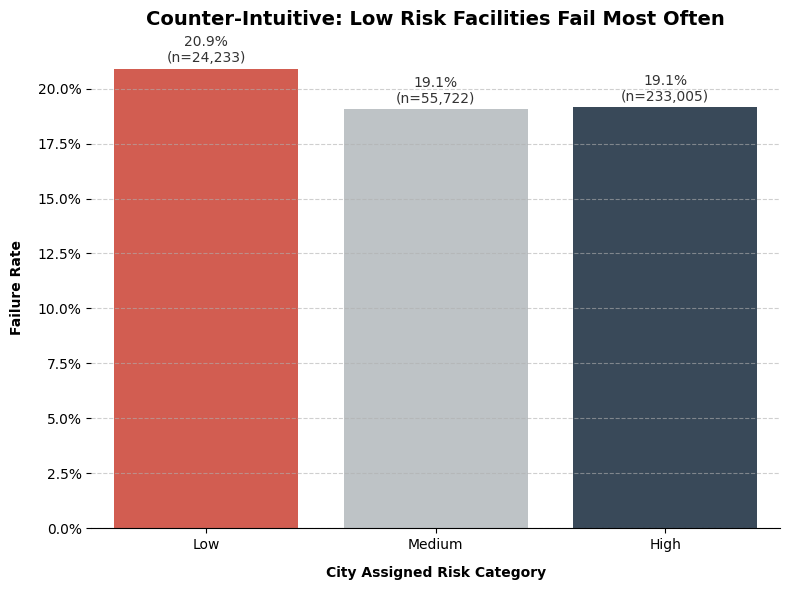

In [29]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(8, 6))

# Highlight 'Low' risk in red to draw attention to the anomaly
custom_colors = ['#e74c3c', '#bdc3c7', '#34495e'] 

sns.barplot(
    data=risk_stats, 
    x='risk', 
    y='mean', 
    palette=custom_colors,
    ax=ax
)

# Clean up aesthetics
sns.despine(left=True, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_title('Counter-Intuitive: Low Risk Facilities Fail Most Often', fontsize=14, pad=15, weight='bold')
ax.set_ylabel('Failure Rate', weight='bold', labelpad=10)
ax.set_xlabel('City Assigned Risk Category', weight='bold', labelpad=10)

# Add cleaner, combined labels
for i, p in enumerate(ax.patches):
    count = risk_stats.iloc[i]['count']
    rate = p.get_height()
    # Put the percentage and the n-count directly above the bar
    ax.text(p.get_x() + p.get_width()/2., rate + 0.003, 
            f'{rate:.1%}\n(n={int(count):,})', 
            ha='center', fontsize=10, color='#333333')

plt.tight_layout()
plt.show()